**RQ8: Which events generate the most media attention in German media outlets?**

Source: `locations_added.csv` and `documentidentifier_id.csv` 

We join both tables on `GKGRECORDID` to get per-document information about outlet, date, persons, locations, tone and a unique document identifier.

In [89]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")


In [90]:
events_path = "/Users/beytuygt/DataScienceProjectGroup8/Data/tagesschau_zdf_pbs_events.csv"
df = pd.read_csv(events_path)

display(df.head())
print(df.columns)


,SQLDATE,SOURCEURL,AvgTone,NumArticles,Actor1Name,Actor2Name,EventCode
0,20231008,https://www.kpbs.org/podcasts/kpbs-midday-edit...,-0.418098,10,UNITED STATES,VOTER,120
1,20231008,https://www.tagesschau.de/inland/debatte-hilfe...,-2.707930,10,POLITICIAN,NaN,138
2,20231008,https://www.tagesschau.de/ausland/asien/gaza-i...,-5.212121,6,ISRAELI,NaN,181
3,20231008,https://nhpbs.org/schedule/summary.aspx?progId...,2.867384,8,CALIFORNIA,NaN,120
4,20231008,https://www.pbs.org/newshour/nation/5-things-t...,2.768166,1,NATIVE PEOPLE,NaN,51


Index(['SQLDATE', 'SOURCEURL', 'AvgTone', 'NumArticles', 'Actor1Name',
       'Actor2Name', 'EventCode'],
      dtype='object')


In [91]:
GERMAN_DOMAINS = ["tagesschau.de", "zdf.de", "bild.de"]
pattern = "|".join(GERMAN_DOMAINS)

df_de = df[df["SOURCEURL"].str.contains(pattern, na=False)].copy()

print(f"Alle Events: {len(df):,}")
print(f"Events in deutschen Medien: {len(df_de):,}")
display(df_de.head())


Alle Events: 56,981
Events in deutschen Medien: 13,037


,SQLDATE,SOURCEURL,AvgTone,NumArticles,Actor1Name,Actor2Name,EventCode
1,20231008,https://www.tagesschau.de/inland/debatte-hilfe...,-2.707930,10,POLITICIAN,NaN,138
2,20231008,https://www.tagesschau.de/ausland/asien/gaza-i...,-5.212121,6,ISRAELI,NaN,181
11,20231008,https://www.tagesschau.de/ausland/asien/gaza-i...,-5.212121,4,ISRAELI,ISRAEL,181
12,20231008,https://www.tagesschau.de/inland/regional/berl...,-6.902655,10,CHANCELLOR,ISRAELI,173
27,20231008,https://www.tagesschau.de/eilmeldung/gaza-isra...,-4.572098,4,ISRAELI,ISRAEL,181


In [92]:
df_de["SQLDATE"] = df_de["SQLDATE"].astype(str)
df_de["Datetime"] = pd.to_datetime(df_de["SQLDATE"], format="%Y%m%d", errors="coerce")
df_de["Date"] = df_de["Datetime"].dt.date

display(df_de[["SQLDATE", "Datetime", "Date"]].head())


,SQLDATE,Datetime,Date
1,20231008,2023-10-08,2023-10-08
2,20231008,2023-10-08,2023-10-08
11,20231008,2023-10-08,2023-10-08
12,20231008,2023-10-08,2023-10-08
27,20231008,2023-10-08,2023-10-08


In [93]:
event_stats = (
    df_de
    .groupby("EventCode", as_index=False)
    .agg(
        total_articles=("NumArticles", "sum"),   # Media attention
        num_event_rows=("NumArticles", "size"),  # Amount GDELT-Event rows
        avg_tone=("AvgTone", "mean")             # Avereage Tone
    )
    .sort_values("total_articles", ascending=False)
)

display(event_stats.head(15))


,EventCode,total_articles,num_event_rows,avg_tone
10,20,10238,1344,-2.673767
0,10,7734,1128,-3.339088
23,40,6042,820,-2.460181
31,51,6035,847,-2.071334
58,110,3989,526,-3.396872
101,190,3597,527,-5.046664
62,120,3491,465,-2.967516
92,173,3455,494,-5.385107
59,111,2935,415,-4.321903
21,36,2935,412,-2.596233


In [94]:
#Eventcode-Description Mapping needed in order to interpret the event codes in the top events
event_lookup = pd.read_csv(
    "/Users/beytuygt/DataScienceProjectGroup8/Data/eventcodes.txt",          
    sep="\t",
    header=0,
    encoding="latin1"               
)

event_lookup = event_lookup.rename(
    columns={"CAMEOEVENTCODE": "EventCode", "EVENTDESCRIPTION": "EventDescription"}
)

event_lookup["EventCode"] = event_lookup["EventCode"].astype(str)

display(event_lookup.head(10))


,EventCode,EventDescription
0,01,MAKE PUBLIC STATEMENT
1,010,"Make statement, not specified below"
2,011,Decline comment
3,012,Make pessimistic comment
4,013,Make optimistic comment
5,014,Consider policy option
6,015,Acknowledge or claim responsibility
7,016,Deny responsibility
8,017,Engage in symbolic act
9,018,Make empathetic comment


In [95]:
events_by_code = (
    df_de
    .groupby("EventCode", as_index=False)
    .agg(
        total_articles=("NumArticles", "sum"),
        num_event_rows=("EventCode", "size"),
        avg_tone=("AvgTone", "mean"),
    )
)

events_by_code["EventCode"] = events_by_code["EventCode"].astype(str)
event_lookup["EventCode"] = event_lookup["EventCode"].astype(str)

top_events_labeled = (
    events_by_code
    .merge(event_lookup, on="EventCode", how="left")
    .sort_values("total_articles", ascending=False)
)

display(top_events_labeled.head())


,EventCode,total_articles,num_event_rows,avg_tone,EventDescription
10,20,10238,1344,-2.673767,USE UNCONVENTIONAL MASS VIOLENCE
0,10,7734,1128,-3.339088,DEMAND
23,40,6042,820,-2.460181,NaN
31,51,6035,847,-2.071334,NaN
58,110,3989,526,-3.396872,"Disapprove, not specified below"


In [96]:
TOP_K = 5  # top 5 most important Eventtypes
top_codes = top_events_labeled["EventCode"].astype(str).head(TOP_K).tolist()

# EventCode-Types
df_de = df_de.copy()
df_de["EventCode"] = df_de["EventCode"].astype(str)
event_lookup["EventCode"] = event_lookup["EventCode"].astype(str)

examples = (
    df_de[df_de["EventCode"].isin(top_codes)]
    .merge(event_lookup, on="EventCode", how="left")
    [["EventCode", "EventDescription", "SOURCEURL", "AvgTone", "NumArticles"]]
    .drop_duplicates(subset=["EventCode", "SOURCEURL"])
    .sort_values(["EventCode"])
)

display(examples.head())


,EventCode,EventDescription,SOURCEURL,AvgTone,NumArticles
2287,10,DEMAND,https://www.tagesschau.de/investigativ/wdr/tel...,-4.127358,2
3657,10,DEMAND,https://www.tagesschau.de/ausland/asien/gaza-h...,-2.371542,10
3655,10,DEMAND,https://www.tagesschau.de/ausland/asien/gazast...,-7.107232,10
1074,10,DEMAND,https://www.tagesschau.de/newsticker/liveblog-...,-1.848739,6
1075,10,DEMAND,https://www.tagesschau.de/ausland/europa/strac...,0.270270,10


In [97]:
event_stats["EventCode"] = event_stats["EventCode"].astype(str)

event_stats_labeled = (
    event_stats
    .merge(event_lookup, on="EventCode", how="left")
    .sort_values("total_articles", ascending=False)
)

display(event_stats_labeled.head(15))


,EventCode,total_articles,num_event_rows,avg_tone,EventDescription
0,20,10238,1344,-2.673767,USE UNCONVENTIONAL MASS VIOLENCE
1,10,7734,1128,-3.339088,DEMAND
2,40,6042,820,-2.460181,NaN
3,51,6035,847,-2.071334,NaN
4,110,3989,526,-3.396872,"Disapprove, not specified below"
5,190,3597,527,-5.046664,"Use conventional military force, not specified..."
6,120,3491,465,-2.967516,"Reject, not specified below"
7,173,3455,494,-5.385107,"Arrest, detain, or charge with legal action"
8,111,2935,415,-4.321903,Criticize or denounce
9,36,2935,412,-2.596233,NaN


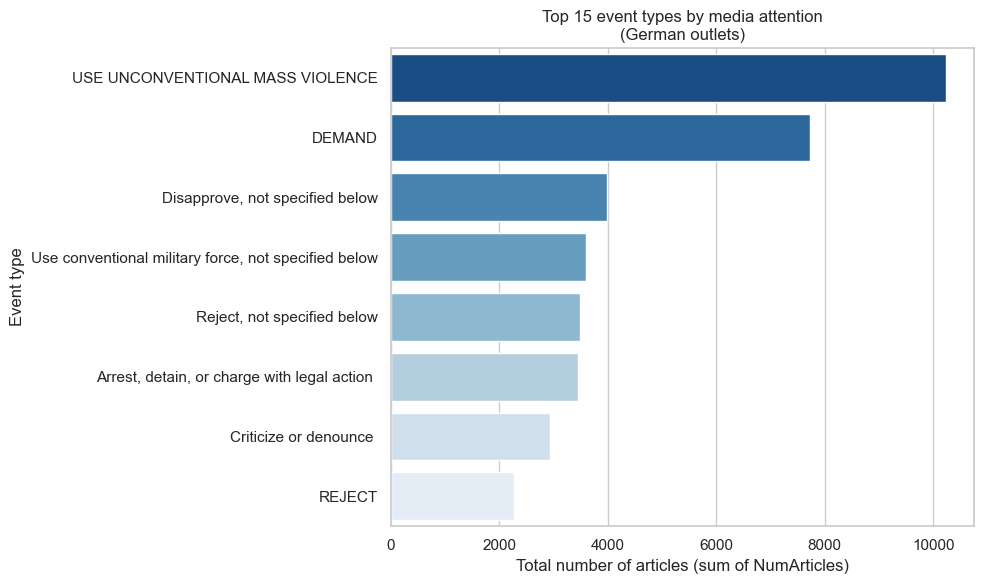

In [98]:
TOP_N = 15

top_events_topN = (
    top_events_labeled
    .sort_values("total_articles", ascending=False)
    .head(TOP_N)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_events_topN,
    x="total_articles",
    y="EventDescription",
    hue="EventDescription",
    dodge=False,
    legend=False,
    palette="Blues_r"
)
plt.title(f"Top {TOP_N} event types by media attention\n(German outlets)")
plt.xlabel("Total number of articles (sum of NumArticles)")
plt.ylabel("Event type")
plt.tight_layout()
plt.show()


In [99]:
# 1) Actor-Spalten in ein langes Format bringen (Actor1 + Actor2)
df_actors_long = (
    pd.concat(
        [
            df_de[["EventCode", "NumArticles", "Actor1Name"]]
            .rename(columns={"Actor1Name": "ActorName"})
            .dropna(subset=["ActorName"]),
            df_de[["EventCode", "NumArticles", "Actor2Name"]]
            .rename(columns={"Actor2Name": "ActorName"})
            .dropna(subset=["ActorName"]),
        ],
        ignore_index=True,
    )
)

# 2) pro EventCode und Actor die Artikel aufsummieren
event_actor = (
    df_actors_long
    .groupby(["EventCode", "ActorName"], as_index=False)
    .agg(total_articles=("NumArticles", "sum"))
)

event_actor.head()
event_actor.columns


Index(['EventCode', 'ActorName', 'total_articles'], dtype='object')

In [100]:
TOP_ACTORS = 5  # Top 5 actors per Eventtype

codes_focus = top_events_labeled["EventCode"].astype(str).tolist()

event_actor["EventCode"] = event_actor["EventCode"].astype(str)

event_actor_sub = event_actor[event_actor["EventCode"].isin(codes_focus)].copy()

event_actor_sub["rank"] = (
    event_actor_sub
    .groupby("EventCode")["total_articles"]
    .rank("dense", ascending=False)
)

event_actor_top = event_actor_sub[event_actor_sub["rank"] <= TOP_ACTORS].copy()
event_actor_top.head()


,EventCode,ActorName,total_articles,rank
114,10,GERMAN,262,5.0
115,10,GERMANY,263,4.0
117,10,GOVERNMENT,312,2.0
144,10,ISRAEL,276,3.0
145,10,ISRAELI,366,1.0


In [101]:
# Mapping EventCode -> EventDescription aus top_events_labeled bauen
code_to_label = (
    top_events_labeled[["EventCode", "EventDescription"]]
    .drop_duplicates()
    .set_index("EventCode")["EventDescription"]
    .to_dict()
)

# sicherstellen, dass die Typen übereinstimmen
event_actor_top["EventCode"] = event_actor_top["EventCode"].astype(str)
# falls top_events_labeled.EventCode int war:
# top_events_labeled["EventCode"] = top_events_labeled["EventCode"].astype(str)

# Label auf event_actor_top mappen
event_actor_top["EventLabel"] = event_actor_top["EventCode"].map(code_to_label)


In [102]:
# Name des Events, für das du die Top-Actors sehen willst
event_name_focus = "USE UNCONVENTIONAL MASS VIOLENCE"

# Daten für dieses Event herausfiltern
actors_20_top = (
    event_actor_top[event_actor_top["EventLabel"] == event_name_focus]
    .sort_values("total_articles", ascending=False)
    .head(20)
)

actors_20_top.head()


,EventCode,ActorName,total_articles,rank,EventLabel
3023,20,UKRAINE,914,1.0,USE UNCONVENTIONAL MASS VIOLENCE
2855,20,GERMANY,568,2.0,USE UNCONVENTIONAL MASS VIOLENCE
2856,20,GOVERNMENT,522,3.0,USE UNCONVENTIONAL MASS VIOLENCE
2918,20,MILITARY,450,4.0,USE UNCONVENTIONAL MASS VIOLENCE
2986,20,RUSSIA,430,5.0,USE UNCONVENTIONAL MASS VIOLENCE


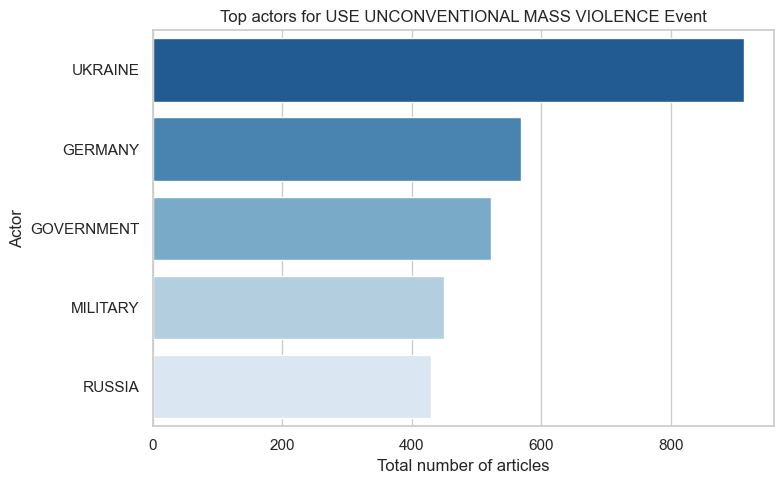

In [103]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=actors_20_top,
    x="total_articles",
    y="ActorName",        # oder Actor1_or_2, je nach Spaltennamen
    hue="ActorName",
    dodge=False,
    legend=False,
    palette="Blues_r"
)
plt.title(f"Top actors for {event_name_focus} Event")
plt.xlabel("Total number of articles")
plt.ylabel("Actor")
plt.tight_layout()
plt.show()


**Interactive plots**:

In [ ]:
import plotly.express as px

TOP_N = 15

top_events_topN = (
    top_events_labeled
    .sort_values("total_articles", ascending=False)
    .head(TOP_N)
    .sort_values("total_articles", ascending=False)
)

fig = px.bar(
    top_events_topN,
    x="total_articles",
    y="EventDescription",
    color="EventDescription",
    orientation="h",
    color_discrete_sequence=px.colors.sequential.Blues_r,
    title=f"Top {TOP_N} event types by media attention<br>(German outlets)",
    labels={"total_articles": "Total Articles"},
)

fig.update_traces(
    hovertemplate=(
        "Event: %{y}<br>" +
        "Total Articles: %{x}" +
        "<extra></extra>"
    )
)

fig.update_layout(
    xaxis_title="Total number of articles",
    yaxis_title="Event type",
    showlegend=False,
    plot_bgcolor="white",
    paper_bgcolor="white",
)

fig.show()


In [112]:
import plotly.express as px

fig = px.bar(
    actors_20_top,
    x="total_articles",
    y="ActorName",
    color="ActorName",  # entspricht hue
    orientation="h",
    color_discrete_sequence=px.colors.sequential.Blues_r,
    title=f"Top actors for {event_name_focus} Event",
    labels={
        "total_articles": "Total Articles",
        "ActorName": "Actor",
    },
    width=900,
    height=500,
)

fig.update_layout(
    xaxis_title="Total number of articles",
    yaxis_title="Actor",
    showlegend=False,
    plot_bgcolor="white",
    paper_bgcolor="white",
)

fig.update_traces(
    hovertemplate="Actor: %{y}<br>Total Articles: %{x}<extra></extra>"
)

fig.show()


In [116]:
import ipywidgets as widgets
from ipywidgets import interact
import plotly.express as px

# Liste der auswählbaren Events (nur die, für die wir Actors haben)
event_options = (
    event_actor_top["EventLabel"]
    .dropna()
    .unique()
)
event_options = sorted(event_options)

TOP_ACTORS = 10  # Limit pro Event

def plot_top_actors(event_name):
    df = (
        event_actor_top[event_actor_top["EventLabel"] == event_name]
        .sort_values("total_articles", ascending=False)
        .head(TOP_ACTORS)  # hier auf 10 begrenzen
    )

    fig = px.bar(
        df,
        x="total_articles",
        y="ActorName",
        color="ActorName",
        orientation="h",
        color_discrete_sequence=px.colors.sequential.Blues_r,
        title=f"Top {TOP_ACTORS} actors for {event_name} Event",
        labels={
            "total_articles": "Total Articles",
            "ActorName": "Actor",
        },
        width=900,
        height=500,
    )

    fig.update_layout(
        xaxis_title="Total number of articles",
        yaxis_title="Actor",
        showlegend=False,
        plot_bgcolor="white",
        paper_bgcolor="white",
    )

    fig.update_traces(
        hovertemplate="Actor: %{y}<br>Total Articles: %{x}<extra></extra>"
    )

    fig.show()

interact(
    plot_top_actors,
    event_name=widgets.Dropdown(
        options=event_options,
        description="Event:",
        value=event_options[0],
        layout=widgets.Layout(width="600px"),
    ),
)


interactive(children=(Dropdown(description='Event:', layout=Layout(width='600px'), options=('ASSAULT', 'Abduct…

<function __main__.plot_top_actors(event_name)>